# VAE Training for Microring Geometry Variation

This notebook:

- loads the microring mask dataframe
- preprocesses the binary edge masks
- trains a convolutional VAE on the processed masks
- saves the best model checkpoint and training metadata
- encodes every ring into a latent vector (`mu`)
- saves a dataframe containing the original metadata and the learned latents

**Expected input:**
A dataframe with a MultiIndex  
`('sample_ID', 'field_ID', 'ring_ID')`  

and a binary mask column:
`binarized_black_edge_norm_faithful`

## Setup and imports

In [ ]:
# Standard library imports
import os
import gc
import json
import time
import random
from pathlib import Path

# Scientific computing and plotting
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Utilities
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, random_split

# Make inline plots a bit sharper in the notebook
plt.rcParams["figure.dpi"] = 140

# Reproducibility
# Set fixed seeds so that results such as initialization,
# random splits, and augmentations are more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Environment check
# Detect whether the notebook is running in Google Colab.
# This helps handle file paths and Drive mounting correctly.
try:
    IN_COLAB = "google.colab" in str(get_ipython())
except NameError:
    IN_COLAB = False

# Google Drive mounting for Colab
# Mount Drive only when running inside Colab.
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

# Device selection
# Use GPU if available, otherwise run on CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


Mounted at /content/drive


device(type='cuda')

## Configuration


In [ ]:

# === Paths ===
pkl_path = "drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/Copy_binarized_only_black_edge_batch_3_v2_norm.pkl"  # Binary masks DF
metadata_path = None  # Metadata with parameters & targets (set to None if already merged)

if IN_COLAB and not os.path.exists('/content/' + pkl_path):
    raise FileNotFoundError(f"Data file not found: {pkl_path}")

# === Outputs (timestamped for uniqueness) ===
experiment_name = time.strftime("vae_geom_aug_conditional_%Y%m%d_%H%M%S")
save_dir_local = f"/content/{experiment_name}" if IN_COLAB else f"./{experiment_name}"
os.makedirs(save_dir_local, exist_ok=True)
if IN_COLAB:
    save_dir_drive = f"/content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/{experiment_name}"
    os.makedirs(save_dir_drive, exist_ok=True)
else:
    save_dir_drive = None
print("Saving to:", save_dir_local, "and", save_dir_drive)

# Saved files for reloading (model, embeddings, results)
model_path        = os.path.join(save_dir_drive or save_dir_local, 'best_vae.pth')
latents_path      = os.path.join(save_dir_drive or save_dir_local, 'df_with_latents.pkl')
hyperparams_path  = os.path.join(save_dir_drive or save_dir_local, 'hyperparameters.json')
samples_png_path  = os.path.join(save_dir_drive or save_dir_local, 'sample_raw_masks.png')
augs_png_path     = os.path.join(save_dir_drive or save_dir_local, 'augmentations.png')
curves_png_path   = os.path.join(save_dir_drive or save_dir_local, 'training_curves.png')

# === VAE / training hyperparameters ===
image_size   = 128   # input image resolution (square)
latent_dim   = 32    # latent dimensionality (compact shape summary)
batch_size   = 16
epochs       = 200
learning_rate= 1e-3
beta_kl      = 1.0
patience     = 15
min_delta    = 1e-4

# === Shape standardization & augmentation toggles ===
do_align_orientation = False  # Prefer D4 augmentation for invariance
do_match_area        = False  # Optional area normalization (off by default)
use_D4_augmentation  = True   # Random rot90 + flips during training
use_TTA_encoding     = True   # D4 test-time augmentation when encoding latents

# === Analysis settings (saved for Notebook 2) ===
pairs      = [('L1','L2'), ('M1','M2'), ('N1','N2'), ('O1','O2')]
fields     = list(range(1, 10))
param_cols = ["diameter", "pitch", "nQWs", "growth_Temp_QW", "AsP_QW", "InP_barrier", "growth_time_cap"]
y_cols     = ["lasing_threshold_corr_from_2", "lasing_wl_corr_from_2"]
n_perm_mmd   = 500
n_perm_delta = 200
n_perm_sample= 1000


# Save hyperparameters for the Analysis notebook
hyperparams = dict(
    latent_dim=latent_dim, image_size=image_size, batch_size=batch_size,
    epochs=epochs, learning_rate=learning_rate, beta_kl=beta_kl,
    patience=patience, min_delta=min_delta,
    do_align_orientation=do_align_orientation, do_match_area=do_match_area,
    use_D4_augmentation=use_D4_augmentation, use_TTA_encoding=use_TTA_encoding,
    pairs=pairs, fields=fields, param_cols=param_cols, y_cols=y_cols,
    n_perm_mmd=n_perm_mmd, n_perm_delta=n_perm_delta, n_perm_sample=n_perm_sample
)
with open(hyperparams_path, 'w') as f:
    json.dump(hyperparams, f, indent=2)
print(f"Saved hyperparameters → {hyperparams_path}")


Saving to: /content/vae_geom_aug_conditional_20260303_211434 and /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434
Saved hyperparameters → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/hyperparameters.json


## Load & validate the dataset

In [ ]:
def read_any(path):
    """Robust file reader supporting pkl, parquet, csv with error handling."""
    if path is None:
        return None
    full_path = '/content/' + path if IN_COLAB and path.startswith('drive/') else path
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")
    ext = os.path.splitext(path)[-1].lower()
    try:
        if ext == ".pkl":
            return pd.read_pickle(full_path)
        if ext == ".parquet":
            return pd.read_parquet(full_path)
        if ext == ".csv":
            df_csv = pd.read_csv(full_path)
            # Expect MultiIndex cols in CSV too
            return df_csv.set_index(["sample_ID","field_ID","ring_ID"])
        raise ValueError(f"Unsupported extension: {ext}")
    except Exception as e:
        raise RuntimeError(f"Error reading {path}: {e}")

# Load main dataframe (binary masks)
df = read_any(pkl_path)

# Validate index and required columns
assert isinstance(df.index, pd.MultiIndex), "Expected MultiIndex index"
assert set(df.index.names) == {"sample_ID", "field_ID", "ring_ID"}, \
    "Expected MultiIndex [sample_ID, field_ID, ring_ID]"
assert 'binarized_black_edge_norm_faithful' in df.columns, "Required 'binarized_black_edge_norm_faithful' column missing"

# Load and merge metadata if provided
meta = read_any(metadata_path)
if meta is not None:
    if 'binarized_black_edge_norm_faithful' in meta.columns:
        meta = meta.drop(columns=['binarized_black_edge_norm_faithful'])  # avoid duplication
    df = df.join(meta, how="left")

# Validate parameter & target columns (for saving alongside latents)
missing_params  = [c for c in param_cols if c not in df.columns]
missing_targets = [c for c in y_cols     if c not in df.columns]
if missing_params:
    raise ValueError(f"Missing parameter columns: {missing_params}")
if missing_targets:
    raise ValueError(f"Missing target columns: {missing_targets}")

# Drop rows with missing key data
df = df.dropna(subset=['binarized_black_edge_norm_faithful'] + param_cols + y_cols)
print("Rows:", len(df),
      "| sample_IDs:", sorted(df.index.get_level_values(0).unique())[:10], "..."
)
gc.collect();


Rows: 6000 | sample_IDs: ['L1', 'L2', 'M1', 'M2', 'N1', 'N2', 'O1', 'O2'] ...


## Binary Microring image (mask) preprocessing

In this section, each binary mask is resized and optionally normalized for area or aligned by orientation. The processed masks are stored in a new dataframe column for model training.

In [ ]:
def preprocess_mask(mask, size=image_size, match_area=do_match_area, align=do_align_orientation):
    """
    Preprocess a single binary microring mask before VAE training.

    The preprocessing steps are:
    1. convert the input to a NumPy array if needed
    2. keep only one channel if the mask is accidentally multi-channel
    3. resize the mask to the target image size
    4. optionally normalize the mask area toward the dataset median area
    5. optionally align the mask orientation using image moments
    6. return the processed mask as float32 scaled to [0, 1]
    """
    # Convert the input to a NumPy array if it is not already one
    if not isinstance(mask, np.ndarray):
        mask = np.array(mask)

    # If the stored mask has multiple channels, keep only the first one
    # This handles cases where a binary mask was saved as an RGB-like image
    if mask.ndim == 3:
        mask = mask[..., 0]

    # Resize the mask to the fixed training resolution
    # Nearest-neighbour interpolation is used so that binary edges remain sharp
    mask = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)

    # Optionally normalize the object area
    # This rescales the mask so that its foreground area is closer to the
    # median foreground area across the dataset
    if match_area:
        current_area = np.sum(mask > 0)
        target_area = np.median([
            np.sum(np.array(m) > 0)
            for m in df["binarized_black_edge_norm_faithful"]
        ])

        if current_area > 0 and target_area > 0:
            scale = np.sqrt(target_area / current_area)

            # Resize according to the computed scale factor
            mask = cv2.resize(
                mask,
                None,
                fx=scale,
                fy=scale,
                interpolation=cv2.INTER_NEAREST,
            )

            # Resize back to the fixed output shape expected by the model
            # This keeps the pipeline simple, without explicit recentering,
            # padding, or cropping steps
            mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

    # Optionally align the mask orientation using image moments
    # This estimates a principal direction from the binary shape and rotates
    # the image to reduce orientation variation across samples
    if align:
        moments = cv2.moments(mask)

        # Only proceed if the mask contains a nonzero foreground region
        if moments["m00"] != 0:
            cx = int(moments["m10"] / moments["m00"])
            cy = int(moments["m01"] / moments["m00"])

            angle = 0.5 * np.arctan2(
                2 * moments["mu11"],
                moments["mu20"] - moments["mu02"]
            )

            rot_mat = cv2.getRotationMatrix2D((cx, cy), np.degrees(angle), 1.0)

            mask = cv2.warpAffine(
                mask,
                rot_mat,
                (size, size),
                flags=cv2.INTER_NEAREST,
            )

    # Convert to float32 and scale pixel values to [0, 1]
    return mask.astype(np.float32) / 255.0


# Apply preprocessing to all masks with a progress bar
# The processed masks are stored in a new dataframe column used for training
df["binary_proc"] = [
    preprocess_mask(m)
    for m in tqdm(df["binarized_black_edge_norm_faithful"], desc="Preprocessing masks")
]

# Drop the original raw mask column to reduce memory usage
# The processed version is sufficient for the rest of this notebook
df = df.drop(columns=["binarized_black_edge_norm_faithful"])

# Run garbage collection explicitly after the dataframe update
gc.collect()


Preprocessing masks:   0%|          | 0/6000 [00:00<?, ?it/s]

## Visualization

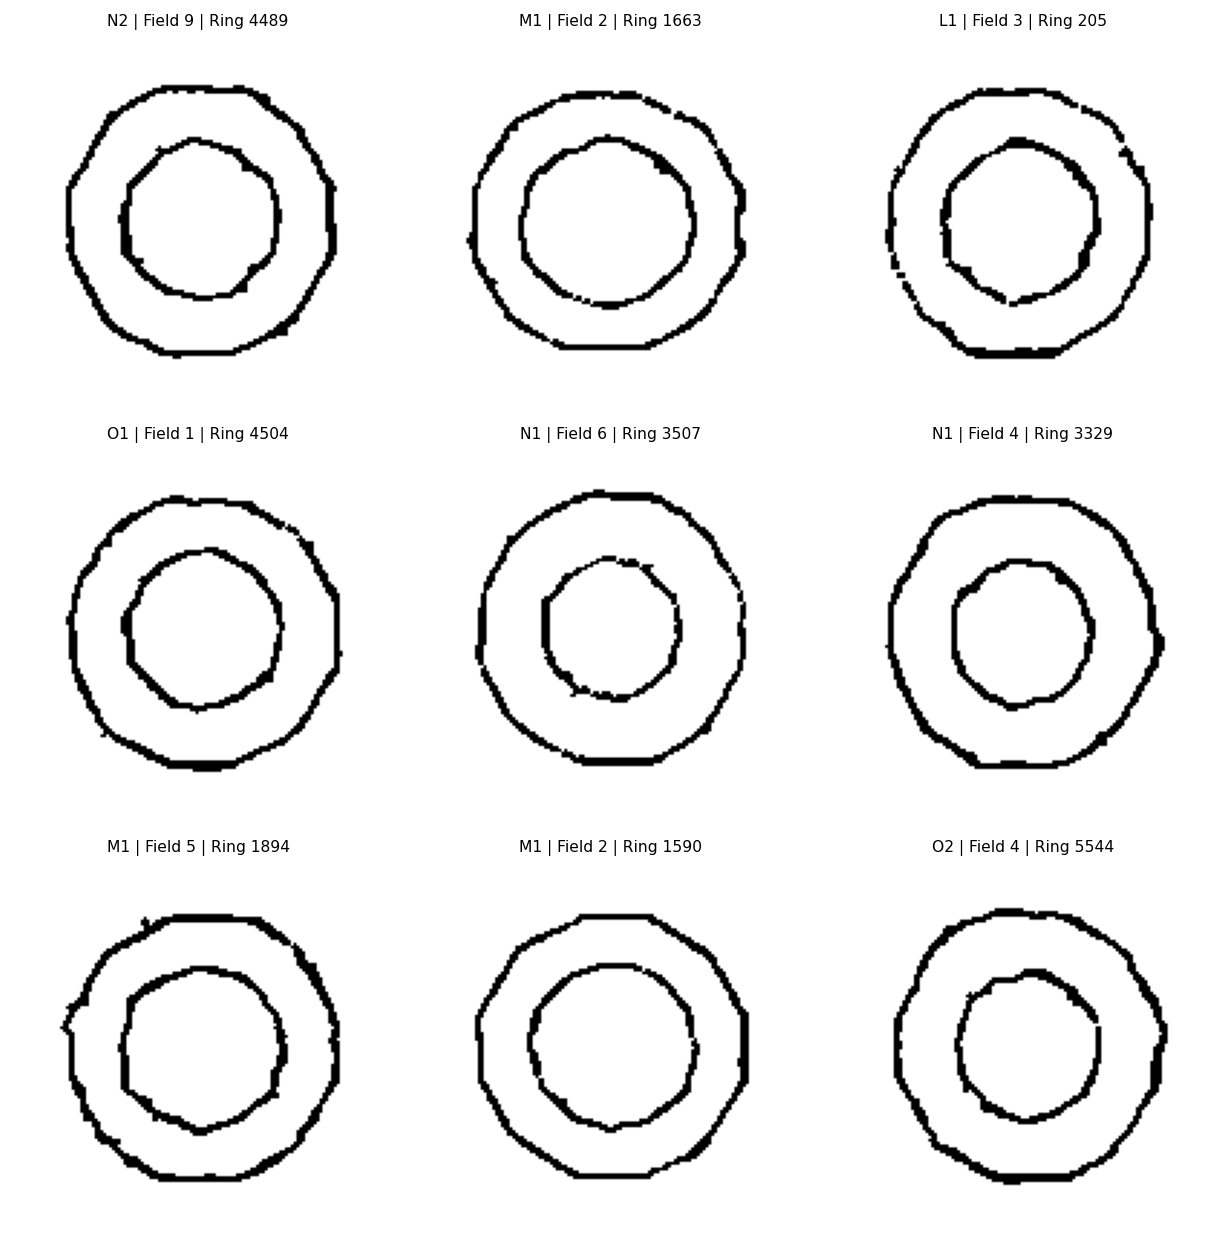

Saved sample raw masks → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/sample_raw_masks.png


In [ ]:
# ============================================================
# Visualize a few raw binary masks
# This is just a sanity check.
# ============================================================
n_show = min(9, len(df))
sel_idx = random.sample(range(len(df)), n_show)

fig, axs = plt.subplots(3, 3, figsize=(9, 9))
for ax, i in zip(axs.flatten(), sel_idx):
    mask = df['binarized_black_edge_norm_faithful'].iloc[i]
    ax.imshow(np.array(mask), cmap='binary_r')
    s, f, r = df.index[i]
    ax.set_title(f"{s} | Field {f} | Ring {r}", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.savefig(samples_png_path); plt.show()
print("Saved sample raw masks →", samples_png_path)


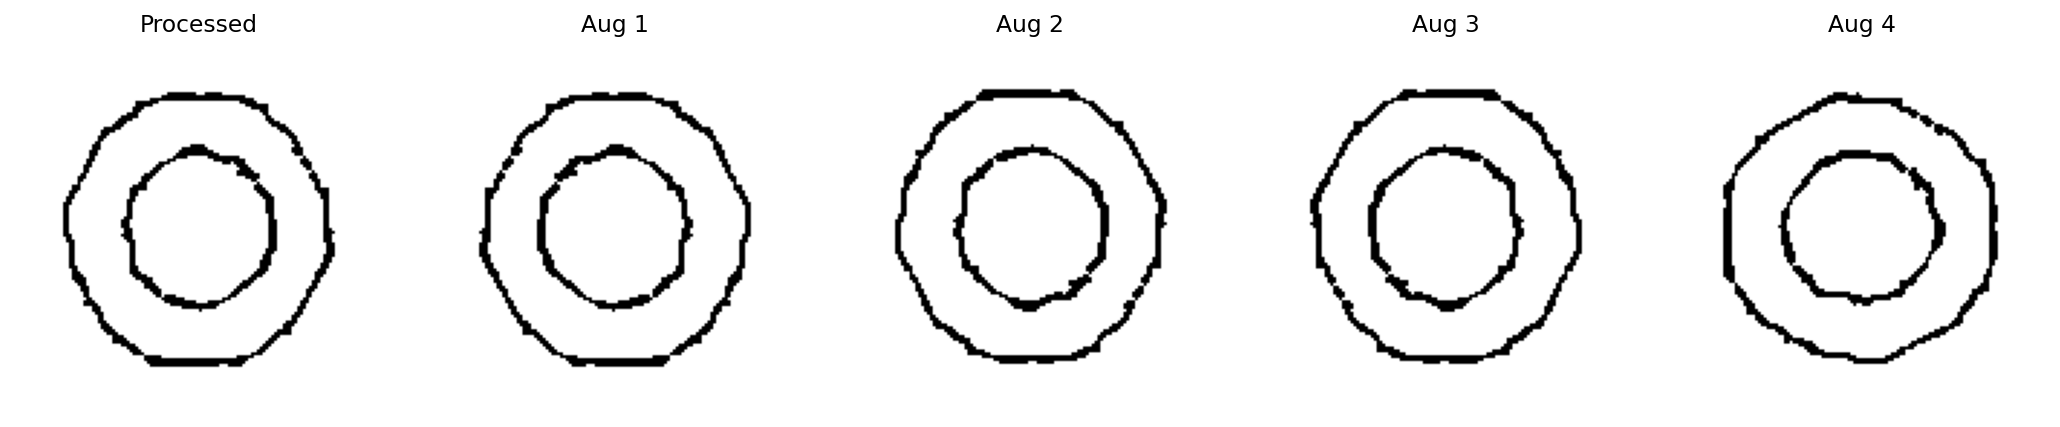

Saved augmentations → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/augmentations.png


In [ ]:
# ============================================================
# Quick preview of D4-style augmentations
# ============================================================
def plot_augmentations(mask, n_aug=4):
    """Plot original processed mask and n augmented versions."""
    fig, axs = plt.subplots(1, n_aug + 1, figsize=(3*(n_aug+1), 3))
    axs[0].imshow(mask, cmap='gray'); axs[0].set_title('Processed'); axs[0].axis('off')
    for i in range(1, n_aug + 1):
        aug = np.rot90(mask, random.randint(0, 3))
        if random.random() > 0.5: aug = np.fliplr(aug)
        if random.random() > 0.5: aug = np.flipud(aug)
        axs[i].imshow(aug, cmap='gray'); axs[i].set_title(f'Aug {i}'); axs[i].axis('off')
    plt.tight_layout(); plt.savefig(augs_png_path); plt.show()
    print("Saved augmentations →", augs_png_path)

plot_augmentations(df['binary_proc'].iloc[0])


## Dataset and dataloaders

In [ ]:
# Dataset class for binary microring masks
# This wraps the processed mask arrays so they can be used directly
# with PyTorch DataLoaders.
class MaskDataset(Dataset):
    """
    PyTorch dataset for binary microring masks.

    Each sample is returned as a tensor of shape [1, H, W], where the
    leading dimension is the single image channel.

    If augmentation is enabled, a random D4-style transformation is
    applied on the fly using:
    - a random rotation by 0°, 90°, 180°, or 270°
    - an optional left-right flip
    - an optional up-down flip
    """
    def __init__(self, masks, augment=True):
        # Store the processed masks
        self.masks = masks

        # Whether to apply random geometric augmentation during training
        self.augment = augment

    def __len__(self):
        # Return the total number of masks in the dataset
        return len(self.masks)

    def __getitem__(self, idx):
        # Retrieve one processed binary mask
        m = self.masks[idx]

        # Apply random D4-style augmentation if enabled
        if self.augment:
            # Randomly choose one of four 90-degree rotations
            k = random.randint(0, 3)
            m = np.rot90(m, k)

            # Random horizontal flip with 50% probability
            if random.random() > 0.5:
                m = np.fliplr(m)

            # Random vertical flip with 50% probability
            if random.random() > 0.5:
                m = np.flipud(m)

            # Ensure the array is stored contiguously in memory
            # before converting it to a PyTorch tensor
            m = np.ascontiguousarray(m)

        # Convert the mask to a float tensor and add a channel dimension
        # Final shape becomes [1, H, W]
        return torch.from_numpy(m).unsqueeze(0).float()


# Create the full dataset from the processed binary masks
dataset = MaskDataset(
    df["binary_proc"].values,
    augment=use_D4_augmentation
)

# Split the dataset into training and validation subsets
# A fixed random seed is used so the split is reproducible
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Create DataLoaders for batching and efficient iteration
# Training data is shuffled each epoch, while validation data is not
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2 if torch.cuda.is_available() else 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2 if torch.cuda.is_available() else 0,
)

# Show the number of samples in each split
print(f"Train={len(train_dataset)}, Val={len(val_dataset)}")


Train=4800, Val=1200


##  Variational Autoencoder (VAE): Model Structure and Training

The model compresses each binary mask into a latent representation of dimension `latent_dim`, then reconstructs the mask from that latent code.

Training minimizes:

$$
\mathcal{L} = \mathrm{BCE}_{\mathrm{recon}} + \beta \,\mathrm{KL}
$$

where:

- **BCE** encourages accurate reconstruction of the mask
- **KL** regularizes the latent space toward a standard normal distribution
- **β** controls the strength of the latent regularization

### Save the VAE model class for reuse

The VAE architecture is written to a standalone Python file.  
This makes it possible to reuse the exact same model definition later in analysis notebooks for loading trained weights, extracting latent vectors, and reconstructing masks, without redefining the class each time.

In [ ]:
%%writefile /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_model.py

# Save the VAE architecture to a standalone Python file so that the
# same model class can be imported later in analysis or inference notebooks.


import torch
import torch.nn as nn


class VAE(nn.Module):
    """
    Convolutional Variational Autoencoder for binary microring masks.

    The model:
    - encodes a single-channel binary mask into a latent representation
    - predicts the latent mean (mu) and log-variance (logvar)
    - samples a latent vector using the reparameterization trick
    - decodes the latent vector back into a reconstructed mask
    """
    def __init__(self, latent_dim, image_size=128):
        super().__init__()

        # Store basic model settings
        self.image_size = int(image_size)
        self.latent_dim = int(latent_dim)

        # Encoder
        # Input shape: [B, 1, 128, 128]
        # After four stride-2 convolutions: [B, 256, 8, 8]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Flatten()
        )

        # Compute the spatial size after four downsampling steps
        hw = self.image_size // 16
        flatten_size = 256 * hw * hw

        # Latent distribution heads
        # These produce the mean and log-variance of the latent Gaussian
        self.fc_mu = nn.Linear(flatten_size, self.latent_dim)
        self.fc_logvar = nn.Linear(flatten_size, self.latent_dim)

        # Decoder input projection
        # This expands the latent vector back to the flattened feature-map size
        self.decoder_input = nn.Linear(self.latent_dim, flatten_size)

        # Decoder
        # This upsamples the latent feature map back to the original image size
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        """
        Encode an input batch into latent mean and log-variance.
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)

        # Clamp log-variance for numerical stability during training
        logvar = self.fc_logvar(h).clamp(min=-10, max=10)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Sample a latent vector using the reparameterization trick.

        z = mu + eps * std, where eps ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """
        Decode a latent vector back into an image reconstruction.
        """
        h = self.decoder_input(z)

        # Reshape the flattened vector back into a feature map
        hw = self.image_size // 16
        h = h.view(-1, 256, hw, hw)

        return self.decoder(h)

    def forward(self, x):
        """
        Full forward pass through the VAE.

        Returns:
        - xhat: reconstructed image
        - mu: latent mean
        - logvar: latent log-variance
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar


Writing /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_model.py


Later, in an analysis notebook, the same model class can be imported using:

```python
from vae_model import VAE

## Model training and monitoring
 
The training loop tracks both training and validation losses across epochs and applies early stopping to prevent unnecessary overtraining once validation performance stops improving.

Alongside the loss terms, two simple image-level diagnostics are monitored on the training set:

- **IoU (intersection over union):** measures the overlap between the thresholded reconstruction and the target mask
- **Pixel accuracy:** measures the fraction of pixels reconstructed correctly after thresholding

The best-performing model, based on validation loss, is saved automatically.  
At the end of training, the loss curves are plotted and the final run configuration is saved again for record keeping.

Epoch 1/200 Train:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/200 Val:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/200: Train Loss=3359.5530 (BCE=3004.5472, KL=355.0058), Val Loss=2249.7415 (BCE=2233.3661, KL=16.3754), IoU=0.925, PixelAcc=0.926, Patience=0/15, Impr=inf


Epoch 2/200 Train:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/200 Val:   0%|          | 0/75 [00:00<?, ?it/s]

...

Epoch 89/200 Val:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 89/200: Train Loss=753.3774 (BCE=677.1056, KL=76.2718), Val Loss=803.5436 (BCE=726.7639, KL=76.7797), IoU=0.982, PixelAcc=0.983, Patience=13/15, Impr=0.0000


Epoch 90/200 Train:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 90/200 Val:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 90/200: Train Loss=753.9357 (BCE=677.9046, KL=76.0311), Val Loss=801.5207 (BCE=724.8913, KL=76.6294), IoU=0.982, PixelAcc=0.983, Patience=14/15, Impr=0.0000
Early stopping after 90 epochs. Best Val Loss: 799.2110
Model saved at: /content/vae_geom_aug_conditional_20260303_211434/best_vae.pth
Also saved at: /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/best_vae.pth


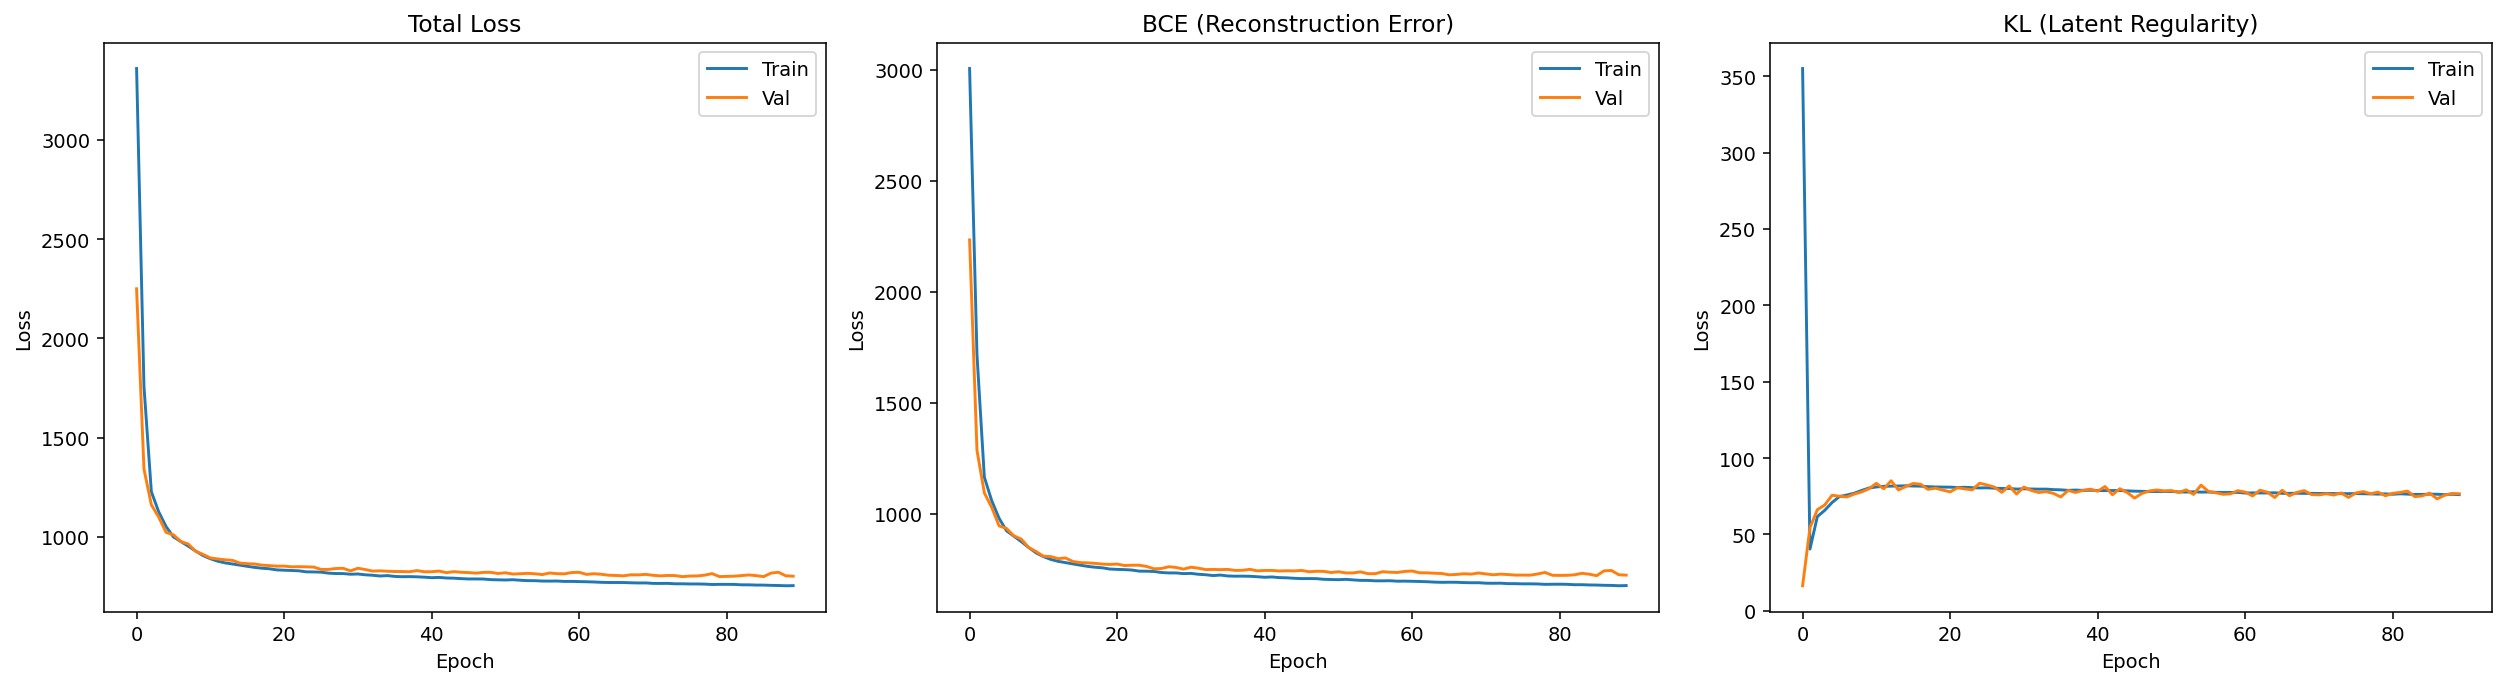

Saved training curves → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/training_curves.png
Hyperparameters saved → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/hyperparameters.json


In [ ]:
# Utility metric for binary mask overlap
# This computes the mean intersection-over-union (IoU) over a batch
# after thresholding the reconstructed output.
@torch.no_grad()
def batch_iou(pred, target, thr=0.5, eps=1e-8):
    # Convert predictions and targets to binary masks
    pred_b = (pred > thr).float()
    targ_b = (target > 0.5).float()

    # Compute intersection and union per image
    inter = (pred_b * targ_b).sum(dim=(1, 2, 3))
    union = (pred_b + targ_b - pred_b * targ_b).sum(dim=(1, 2, 3))

    # Return the mean IoU across the batch
    return ((inter + eps) / (union + eps)).mean().item()


# VAE loss function
# The total loss combines:
# - binary cross-entropy reconstruction loss
# - KL divergence regularization weighted by beta
def vae_loss(recon, x, mu, logvar, beta=beta_kl):
    """
    Compute the VAE loss.

    Returns
    -------
    total_loss : torch.Tensor
        Combined reconstruction + KL loss
    BCE : torch.Tensor
        Reconstruction loss
    KL : torch.Tensor
        KL divergence term
    """
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return BCE + beta * KL, BCE, KL


# Optimizer
# Adam is used for stable gradient-based optimization
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Variables used for early stopping
best_val_loss = float("inf")
patience_counter = 0

# Containers to store training history
train_losses, val_losses = [], []
train_bce, train_kl = [], []
val_bce, val_kl = [], []
train_iou = []
train_pixel_acc = []

# Main training loop
for epoch in range(epochs):

    # ---------------------------
    # Training phase
    # ---------------------------
    # Enable training mode so layers such as dropout/batchnorm (if present)
    # behave appropriately during optimization.
    model.train()

    # Running accumulators for this epoch
    tr_loss = tr_bce = tr_kl = tr_iou = tr_acc = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Train"):
        # Move the batch to the selected device
        batch = batch.to(device)

        # Forward pass through the VAE
        recon, mu, logvar = model(batch)

        # Compute the loss and its components
        loss, bce, kl = vae_loss(recon, batch, mu, logvar)

        # Standard optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate batch-level statistics
        tr_loss += loss.item()
        tr_bce += bce.item()
        tr_kl += kl.item()

        # Compute reconstruction-quality metrics
        tr_iou += batch_iou(recon, batch)

        # Pixel accuracy after thresholding reconstructions at 0.5
        tr_acc += (recon > 0.5).float().eq(batch).float().mean().item()

    # Store mean training statistics for this epoch
    train_losses.append(tr_loss / len(train_loader))
    train_bce.append(tr_bce / len(train_loader))
    train_kl.append(tr_kl / len(train_loader))
    train_iou.append(tr_iou / len(train_loader))
    train_pixel_acc.append(tr_acc / len(train_loader))

    # ---------------------------
    # Validation phase
    # ---------------------------
    # Switch to evaluation mode and disable gradient tracking
    model.eval()

    va_loss = va_bce = va_kl = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Val"):
            # Move validation batch to device
            batch = batch.to(device)

            # Forward pass
            recon, mu, logvar = model(batch)

            # Compute validation loss
            loss, bce, kl = vae_loss(recon, batch, mu, logvar)

            # Accumulate validation statistics
            va_loss += loss.item()
            va_bce += bce.item()
            va_kl += kl.item()

    # Store mean validation statistics for this epoch
    val_losses.append(va_loss / len(val_loader))
    val_bce.append(va_bce / len(val_loader))
    val_kl.append(va_kl / len(val_loader))

    # Compute how much the validation loss improved relative to the
    # best value seen so far
    improvement = best_val_loss - val_losses[-1] if val_losses[-1] < best_val_loss else 0.0

    # Print a compact training summary for the current epoch
    print(
        f"Epoch {epoch+1}/{epochs}: "
        f"Train Loss={train_losses[-1]:.4f} (BCE={train_bce[-1]:.4f}, KL={train_kl[-1]:.4f}), "
        f"Val Loss={val_losses[-1]:.4f} (BCE={val_bce[-1]:.4f}, KL={val_kl[-1]:.4f}), "
        f"IoU={train_iou[-1]:.3f}, PixelAcc={train_pixel_acc[-1]:.3f}, "
        f"Patience={patience_counter}/{patience}, Impr={improvement:.4f}"
    )

    # ---------------------------
    # Early stopping and checkpoint saving
    # ---------------------------
    # Save the model whenever the validation loss improves by at least min_delta.
    if val_losses[-1] < best_val_loss - min_delta:
        best_val_loss = val_losses[-1]
        patience_counter = 0

        # Save a local copy of the best model checkpoint
        local_path = os.path.join(save_dir_local, "best_vae.pth")
        torch.save(model.state_dict(), local_path)

        # If running with a separate Drive directory, save there as well
        if save_dir_drive:
            drive_path = model_path
            torch.save(model.state_dict(), drive_path)

        # Save using the main model path
        torch.save(model.state_dict(), model_path)

    else:
        # No sufficient improvement this epoch
        patience_counter += 1

        # Stop training once patience is exhausted
        if patience_counter >= patience:
            print(f"Early stopping after {epoch+1} epochs. Best Val Loss: {best_val_loss:.4f}")
            print(f"Model saved at: {local_path}")
            if save_dir_drive:
                print(f"Also saved at: {drive_path}")
            break

    # Explicit garbage collection after each epoch
    gc.collect()


# Plot training curves
# These plots summarize how the total loss, reconstruction loss,
# and KL regularization evolve during training.
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axs[0].plot(train_losses, label="Train")
axs[0].plot(val_losses, label="Val")
axs[0].set_title("Total Loss")
axs[0].legend()
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")

# Reconstruction loss
axs[1].plot(train_bce, label="Train")
axs[1].plot(val_bce, label="Val")
axs[1].set_title("BCE (Reconstruction Error)")
axs[1].legend()
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")

# KL term
axs[2].plot(train_kl, label="Train")
axs[2].plot(val_kl, label="Val")
axs[2].set_title("KL (Latent Regularity)")
axs[2].legend()
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Loss")

plt.tight_layout()
plt.savefig(curves_png_path)
plt.show()

print("Saved training curves →", curves_png_path)

# Save the hyperparameters again at the end of training
# This ensures that the final run directory contains the full
# experiment configuration alongside the trained model.
with open(hyperparams_path, "w") as f:
    json.dump(hyperparams, f, indent=2)

print("Hyperparameters saved →", hyperparams_path)


## Latent encoding

After training, the best checkpoint is reloaded and every processed mask is encoded into its latent mean vector. These latent vectors are then attached to the dataframe for downstream analysis.

In [ ]:
# Encode a single processed binary mask into its latent mean vector mu
# The function optionally applies D4 test-time augmentation (TTA) by
# averaging the latent means from rotated and flipped versions of the mask.
@torch.no_grad()
def encode_mu(model, mask_np, tta=use_TTA_encoding):
    """
    Encode one processed mask into its latent mean vector.

    Parameters
    ----------
    model : torch.nn.Module
        Trained VAE model.
    mask_np : np.ndarray
        Processed binary mask as a 2D NumPy array.
    tta : bool
        If True, apply D4-style test-time augmentation and average the
        resulting latent mean vectors.

    Returns
    -------
    np.ndarray
        Latent mean vector mu for the input mask.
    """
    # Convert the 2D NumPy mask into a PyTorch tensor with shape [1, 1, H, W]
    # where the dimensions are: [batch, channel, height, width]
    x = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)

    # If test-time augmentation is disabled, encode the mask directly
    if not tta:
        mu, _ = model.encode(x)
        return mu.squeeze(0).cpu().numpy()

    # If test-time augmentation is enabled, encode several D4-transformed
    # versions of the same mask and average the resulting latent means
    mus = []

    for k in range(4):
        # Rotate the mask by 0°, 90°, 180°, or 270°
        rot = torch.rot90(x, k, dims=(2, 3))

        # Encode the rotated version
        mu, _ = model.encode(rot)
        mus.append(mu)

        # Encode the horizontally flipped rotated version
        mu, _ = model.encode(torch.fliplr(rot))
        mus.append(mu)

        # Encode the vertically flipped rotated version
        mu, _ = model.encode(torch.flipud(rot))
        mus.append(mu)

    # Average all latent mean vectors obtained from the augmented views
    mu = torch.stack(mus, dim=0).mean(dim=0)

    # Remove the batch dimension and return as a NumPy array
    return mu.squeeze(0).cpu().numpy()


# Reload the best-performing checkpoint before extracting latent vectors
# This ensures that encoding is done using the best model found during training
best_state = torch.load(model_path, map_location=device)
model.load_state_dict(best_state)
model.eval()

# Encode every processed mask in the dataframe
# The resulting latent vectors are stored temporarily in a list
latents = []
for m in tqdm(df["binary_proc"].values, desc="Encoding latents (μ)"):
    latents.append(encode_mu(model, m, tta=use_TTA_encoding))

# Store the latent vectors in a new dataframe column
# Each row now contains a compact learned representation of morphology
df["latent"] = list(np.vstack(latents))

# Drop the processed mask images before saving
# This keeps the saved dataframe smaller and easier to use later
# The raw masks can always be reloaded again from the original source file
df_to_save = df.drop(columns=["binary_proc"])

# Save the dataframe containing:
# - the original MultiIndex
# - parameter columns
# - target columns
# - the learned latent vector for each ring
df_to_save.to_pickle(latents_path)

# Print a short summary of the saved output
print("Saved df_with_latents →", latents_path)
print("Columns saved:", df_to_save.columns.tolist()[:12], "...")


Encoding latents (μ):   0%|          | 0/6000 [00:00<?, ?it/s]

Saved df_with_latents → /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434/df_with_latents.pkl
Columns saved: ['diameter', 'pitch', 'nQWs', 'growth_Temp_QW', 'AsP_QW', 'InP_barrier', 'growth_time_cap', 'lasing_threshold', 'lasing_wavelength', 'Yield', 'lasing_threshold_corr_from_2', 'lasing_wl_corr_from_2'] ...


## Summary

In [ ]:
# Summary - Further Analysis in seperate notebook
print("Experiment folder:", save_dir_drive or save_dir_local)
print(" - best_vae.pth")
print(" - df_with_latents.pkl  (contains MultiIndex + param_cols + y_cols + 'latent')")
print(" - hyperparameters.json")
print(" - training_curves.png, sample_raw_masks.png, augmentations.png")


Experiment folder: /content/drive/MyDrive/MR_Geometry_Variation/Final_Analysis_after_ablation/vae_geom_aug_conditional_20260303_211434
 - best_vae.pth
 - df_with_latents.pkl  (contains MultiIndex + param_cols + y_cols + 'latent')
 - hyperparameters.json
 - training_curves.png, sample_raw_masks.png, augmentations.png
